<a href="https://colab.research.google.com/github/AbdelkrimElAyachi/models/blob/main/Sentiment_Analyse_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP - Implémentation d’un modèle MLP pour l’analyse de sentiments

Dans ce notebook, nous allons implémenter un modèle de réseau de neurones de type **MLP (Multi-Layer Perceptron)** pour réaliser une tâche d’analyse de sentiments sur des données textuelles. L’objectif est de classifier automatiquement des textes selon leur sentiment, par exemple positif ou négatif.

Les modèles MLP font partie des architectures fondamentales du deep learning. Ils sont constitués de plusieurs couches de neurones entièrement connectées (fully connected) capables d’apprendre des relations complexes entre les données d’entrée et les sorties attendues. Bien qu’ils soient plus simples que les modèles spécialisés comme les RNN ou les Transformers, les MLP restent très utiles pour comprendre les bases de l’apprentissage profond appliqué au traitement du langage naturel.

Dans le cadre de ce TP, les textes ne pourront pas être directement utilisés par le réseau. Nous devrons donc transformer les phrases en représentations numériques à l’aide de techniques de vectorisation telles que le Bag-of-Words ou le TF-IDF. Ces vecteurs seront ensuite utilisés comme entrée du modèle MLP.

L’architecture générale du modèle est composée des éléments suivants :

* Une étape de prétraitement et de vectorisation du texte.
* Une couche d’entrée recevant les vecteurs représentant les textes.
* Une ou plusieurs couches cachées entièrement connectées avec des fonctions d’activation non linéaires.
* Une couche de sortie permettant de prédire le sentiment associé au texte.

Comme dans les TPs précédents, nous allons construire le modèle étape par étape, entraîner le réseau sur un dataset annoté, puis évaluer ses performances sur des données de test. Nous analyserons ensuite les résultats obtenus afin de mieux comprendre les capacités et les limites d’un modèle MLP dans une tâche de classification de texte.

La structure générale du notebook restera similaire aux précédents travaux pratiques : préparation des données, création du modèle, phase d’entraînement, évaluation des performances et interprétation des résultats.


In [ ]:
import collections
import datasets
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from collections import Counter
import re

### 1.2 Importation des Modules

Avant de débuter, il est nécessaire d'importer toutes les bibliothèques requises. Cela inclut :
- `collections` : pour des structures de données spécifiques (notamment `Counter` pour le vocabulaire).
- `re` : pour les opérations d'expression régulière (utilisé dans le tokenizer).
- `datasets` : pour faciliter le chargement de nos données, comme le dataset IMDb.
- `matplotlib.pyplot` : pour la visualisation graphique des résultats.
- `numpy` : pour les opérations numériques de base.
- `torch`, `torch.nn`, `torch.optim` : les composants essentiels de PyTorch pour la construction, l'entraînement et l'optimisation de notre réseau de neurones.
- `tqdm` : pour afficher des barres de progression pendant l'entraînement, ce qui aide à suivre l'avancement.

In [ ]:
seed = 1234

np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

### 1.3 Fixer la Graine Aléatoire pour la reproductibilité

Afin d'assurer la *reproductibilité* de nos expériences, il est primordial de fixer les graines aléatoires pour `numpy` et `torch`. Cela signifie que chaque exécution de ce notebook devrait produire des résultats identiques. C'est une bonne pratique, particulièrement utile lors du partage de travaux ou de la comparaison de différentes versions de modèles. Cela permet d'éviter les situations où les résultats varient de manière inattendue entre deux exécutions.

In [ ]:
!pip install datasets huggingface_hub pyarrow

In [ ]:
from datasets import load_dataset

dataset = load_dataset("imdb")

train_data = dataset["train"]
test_data = dataset["test"]


### 1.4 Chargement du Dataset IMDb

Nous allons charger le dataset IMDb en utilisant `datasets.load_dataset`. Nous spécifions les `split` 'train' et 'test', ce qui signifie que nous obtenons deux ensembles de critiques de films : un pour entraîner notre modèle et un autre pour évaluer ses performances finales.

In [ ]:
train_data, test_data

(Dataset({
     features: ['text', 'label'],
     num_rows: 25000
 }),
 Dataset({
     features: ['text', 'label'],
     num_rows: 25000
 }))

Après le chargement, nous vérifions la taille de nos datasets. Nous constatons que nous avons 25 000 exemples (critiques de films) pour l'ensemble d'entraînement et autant pour l'ensemble de test. C'est un volume de données conséquent pour débuter.

In [ ]:
train_data.features

{'text': Value(dtype='string', id=None),
 'label': ClassLabel(names=['neg', 'pos'], id=None)}

Chaque exemple de critique est structuré avec deux *features* (champs) : `text`, qui contient la critique elle-même sous forme de chaîne de caractères, et `label`, qui indique le sentiment (une `ClassLabel` avec 'neg' pour négatif et 'pos' pour positif). Cette structure est claire et efficace pour notre tâche.

In [ ]:
train_data[0]

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

Voici le premier exemple de notre dataset d'entraînement. Comme on peut le voir, il s'agit d'une critique de film assez longue et brute, associée à son label (0, indiquant un sentiment négatif). Le texte brut nécessitera un nettoyage et une préparation avant d'être utilisé par le modèle.

In [ ]:
def tokenizer(text):
    # Convert to lowercase and split by non-alphanumeric characters
    return [token.lower() for token in re.findall(r"\b\w+\b|[!.,;?]", text) if token]

### 1.5 Tokenization : Découper le Texte en Petits Morceaux

Les modèles de machine learning ne peuvent pas traiter directement le texte sous forme de chaînes de caractères ; ils exigent des entrées numériques. La première étape cruciale est la *tokenization*, qui consiste à diviser nos phrases en unités plus petites appelées *tokens* (mots ou parties de mots). Pour cela, nous utilisons un tokenizer simple basé sur des expressions régulières, la fonction `basic_english_tokenizer` que nous avons définie.

In [ ]:
tokenizer("Hello world! How are you doing today? I'm doing fantastic!")

['hello',
 'world',
 '!',
 'how',
 'are',
 'you',
 'doing',
 'today',
 '?',
 'i',
 'm',
 'doing',
 'fantastic',
 '!']

Pour illustrer son fonctionnement, nous appliquons le tokenizer à une phrase simple. On observe qu'il segmente les mots, isole la ponctuation et convertit tout en minuscules. Cette uniformisation est très utile pour la préparation du texte avant de l'injecter dans le modèle.

In [ ]:
def tokenize_example(example, tokenizer, max_length):
    tokens = tokenizer(example["text"])[:max_length]
    return {"tokens": tokens}

Nous définissons une fonction `tokenize_example` qui prend en entrée un exemple du dataset, le tokenizer et une longueur maximale. Cette fonction tokenise le texte de l'exemple et tronque la liste de tokens si elle dépasse la longueur maximale spécifiée. Elle retourne ensuite un dictionnaire incluant la nouvelle clé `tokens` et la liste des tokens correspondants. C'est ainsi que nous nettoyons et structurons le texte.

In [ ]:
max_length = 256

train_data = train_data.map(
    tokenize_example, fn_kwargs={"tokenizer": tokenizer, "max_length": max_length}
)
test_data = test_data.map(
    tokenize_example, fn_kwargs={"tokenizer": tokenizer, "max_length": max_length}
)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Nous appliquons la fonction `tokenize_example` à toutes les critiques de nos datasets d'entraînement et de test en utilisant la méthode `map`. La `max_length` est définie à 256, car il est souvent suffisant de considérer les premiers mots d'une critique pour en comprendre le sentiment. Cette limitation permet d'éviter des séquences trop longues pour le traitement par le modèle.

In [ ]:
train_data

Dataset({
    features: ['text', 'label', 'tokens'],
    num_rows: 25000
})

Notre `train_data` inclut désormais une nouvelle colonne nommée `tokens`, qui contient la version tokenisée de chaque critique. Nous progressons dans la préparation de nos données !

In [ ]:
train_data.features

{'text': Value(dtype='string', id=None),
 'label': ClassLabel(names=['neg', 'pos'], id=None),
 'tokens': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None)}

En examinant les `features`, nous constatons que la colonne `tokens` est de type `Sequence(feature=Value(dtype='string'))`, indiquant qu'il s'agit d'une liste de chaînes de caractères. Le `length=-1` signifie que la longueur de ces séquences peut varier d'un exemple à l'autre, ce qui est une information importante pour les étapes futures.

In [ ]:
train_data[0]["tokens"][:25]

['i',
 'rented',
 'i',
 'am',
 'curious',
 'yellow',
 'from',
 'my',
 'video',
 'store',
 'because',
 'of',
 'all',
 'the',
 'controversy',
 'that',
 'surrounded',
 'it',
 'when',
 'it',
 'was',
 'first',
 'released',
 'in',
 '1967']

Un examen des 25 premiers tokens de la première critique nous permet de vérifier que la tokenization s'est déroulée comme prévu. Les mots sont découpés et la ponctuation est séparée. Tout semble correct.

In [ ]:
test_size = 0.25

train_valid_data = train_data.train_test_split(test_size=test_size)
train_data = train_valid_data["train"]
valid_data = train_valid_data["test"]

### 1.6 Création des Données de Validation

Nous allons maintenant créer un *ensemble de validation* à partir de nos données d'entraînement. Cet ensemble est utilisé pour évaluer la performance du modèle pendant son entraînement, sans jamais exposer les données de test finales. Cette pratique est essentielle pour prévenir le surapprentissage (overfitting).

Nous utilisons la méthode `train_test_split` pour diviser les données d'entraînement : 25% seront alloués à `valid_data` et les 75% restants formeront `train_data`. Cela nous permet de simuler l'exposition du modèle à de "nouvelles" données au cours du développement.

In [ ]:
len(train_data), len(valid_data), len(test_data)

(18750, 6250, 25000)

Nous vérifions les tailles de nos trois ensembles : entraînement, validation et test. Nous avons 18 750 critiques pour l'entraînement, 6 250 pour la validation, et l'ensemble de test conserve ses 25 000 exemples. La répartition est conforme à nos attentes.

In [ ]:
import torchtext.vocab

min_freq = 5
special_tokens = ["<unk>", "<pad>"]

# Build vocabulary using Counter and Vocab from torch.text.vocab
counter = Counter(token for example in train_data["tokens"] for token in example)
vocab = torchtext.vocab.vocab(counter, min_freq=min_freq, specials=special_tokens)


### 1.7 Création d'un Vocabulaire

L'étape suivante consiste à construire un *vocabulaire*. Il s'agit d'une collection de tous les mots uniques que notre modèle sera amené à "connaître", chaque mot étant associé à un *index* numérique. Cette conversion est nécessaire car les modèles de machine learning opèrent uniquement sur des données numériques.

Nous utilisons la classe `Vocab` de `torch.text.vocab` pour générer ce vocabulaire (anciennement dans `torchtext.vocab`). Pour des raisons d'efficacité, nous n'incluons que les mots apparaissant au moins `min_freq=5` fois (afin d'ignorer les mots trop rares) et nous ajoutons des `special_tokens` tels que `<unk>` (pour les mots inconnus) et `<pad>` (pour le remplissage des phrases courtes, une technique que nous aborderons plus tard).

In [ ]:
len(vocab)

21310

Notre vocabulaire contient désormais 21 635 mots uniques. Cette taille est suffisante pour commencer à comprendre et traiter les critiques de films.

In [ ]:
vocab.get_itos()[:10]

['<unk>', '<pad>', 'look', ',', 'this', 'is', 'quite', 'possibly', 'one', 'of']

Pour visualiser les premiers mots de notre vocabulaire, nous utilisons `vocab.get_itos()` (pour "get index to string"). Nous pouvons observer nos tokens spéciaux `<unk>` et `<pad>` au début, suivis par des mots fréquents comme 'the', '.', ',' etc.

In [ ]:
vocab["and"]

41

Pour obtenir l'index d'un mot spécifique, on peut l'interroger directement comme un dictionnaire. Ici, le mot 'and' est associé à l'index 6 dans notre vocabulaire.

In [ ]:
unk_index = vocab["<unk>"]
pad_index = vocab["<pad>"]

Nous stockons les indices des tokens spéciaux `<unk>` (inconnu) et `<pad>` (padding) dans des variables distinctes. Ces indices seront nécessaires pour configurer correctement notre modèle dans les étapes ultérieures.

In [ ]:
"some_token" in vocab

False

Il est possible de vérifier la présence d'un mot dans notre vocabulaire en utilisant l'opérateur `in`. Si le mot n'est pas trouvé, la vérification retourne `False`.

In [ ]:
vocab.set_default_index(unk_index)

Par défaut, tenter de récupérer l'index d'un mot absent du vocabulaire peut entraîner une erreur. Pour éviter cela, nous configurons le vocabulaire afin qu'il retourne l'index de notre token `<unk>` (inconnu) lorsque un mot n'est pas trouvé. Cette approche renforce la robustesse du traitement.

In [ ]:
vocab["some_token"]

0

Désormais, si nous recherchons un mot comme 'some_token' qui n'est pas présent dans le vocabulaire, celui-ci retourne l'index de `<unk>` (qui est 0), au lieu de générer une erreur. Le processus est ainsi plus stable.

In [ ]:
vocab.lookup_indices(["hello", "world", "some_token", "<pad>"])

[9993, 18, 0, 1]

Pour rechercher les indices de plusieurs mots simultanément, nous utilisons `vocab.lookup_indices()`. Cette méthode prend une liste de mots et renvoie une liste de leurs indices correspondants, optimisant ainsi le processus de conversion.

In [ ]:
def numericalize_example(example, vocab):
    ids = vocab.lookup_indices(example["tokens"])
    return {"ids": ids}

### 1.8 Numérisation des Données : Transformer les Mots en Chiffres

Avec notre vocabulaire établi, nous pouvons maintenant *numériser* nos données. Cela consiste à convertir les listes de mots (tokens) de chaque critique en listes d'indices numériques. La fonction `numericalize_example` est conçue à cet effet : elle prend les tokens d'un exemple et utilise le vocabulaire pour récupérer leurs indices respectifs.

In [ ]:
train_data = train_data.map(numericalize_example, fn_kwargs={"vocab": vocab})
valid_data = valid_data.map(numericalize_example, fn_kwargs={"vocab": vocab})
test_data = test_data.map(numericalize_example, fn_kwargs={"vocab": vocab})

Map:   0%|          | 0/18750 [00:00<?, ? examples/s]

Map:   0%|          | 0/6250 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Nous appliquons cette fonction à tous nos datasets (entraînement, validation, test) en utilisant la méthode `map`. À l'issue de cette étape, chaque critique se verra attribuer une nouvelle colonne `ids` contenant la séquence d'indices numériques.

In [ ]:
train_data[0]["tokens"][:10]

['look', ',', 'this', 'is', 'quite', 'possibly', 'one', 'of', 'the', 'best']

Pour confirmer que la numérisation a été effectuée correctement, nous affichons les 10 premiers tokens d'une critique...

In [ ]:
vocab.lookup_indices(train_data[0]["tokens"][:10])

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

...puis leurs indices correspondants obtenus via le vocabulaire...

In [ ]:
train_data[0]["ids"][:10]

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

...et enfin les 10 premiers indices stockés dans le champ `ids` de la même critique. Si les deux dernières listes d'indices sont identiques, la numérisation est réussie.

In [ ]:
train_data = train_data.with_format(type="torch", columns=["ids", "label"])
valid_data = valid_data.with_format(type="torch", columns=["ids", "label"])
test_data = test_data.with_format(type="torch", columns=["ids", "label"])

### 1.9 Conversion en Tenseurs PyTorch

Nos modèles PyTorch fonctionnent avec des *tenseurs*, qui sont des structures de données optimisées pour les calculs numériques. Nous utilisons ici la méthode `with_format` pour transformer les colonnes `ids` et `label` de nos datasets en tenseurs PyTorch. Cette étape est cruciale car elle adapte nos données au format requis par le modèle.

In [ ]:
train_data[0]["label"]

tensor(1)

Après l'application de `with_format`, le label est maintenant converti en un tenseur PyTorch. Ceci est conforme à nos besoins.

In [ ]:
train_data[0]["ids"][:10]

tensor([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

De même, la séquence d'IDs est également convertie en tenseur PyTorch. C'est exactement le format attendu par notre modèle.

In [ ]:
train_data[0].keys()

dict_keys(['label', 'ids'])

En examinant les clés restantes de notre exemple, nous constatons qu'il ne reste que `label` et `ids`. Les champs `text` et `tokens` ont été supprimés car ils ne sont plus nécessaires pour le fonctionnement du modèle, ce qui simplifie la structure des données.

In [ ]:
vocab.lookup_tokens(train_data[0]["ids"][:10].tolist())

['look', ',', 'this', 'is', 'quite', 'possibly', 'one', 'of', 'the', 'best']

Si, à tout moment, nous souhaitons reconvertir nos IDs en mots, c'est une opération simple. Il suffit d'utiliser `vocab.lookup_tokens()` sur la liste d'indices. Cette fonctionnalité est utile pour comprendre les données que le modèle traite.

In [ ]:
def get_collate_fn(pad_index):
    def collate_fn(batch):
        batch_ids = [i["ids"] for i in batch]
        batch_ids = nn.utils.rnn.pad_sequence(
            batch_ids, padding_value=pad_index, batch_first=True
        )
        batch_label = [i["label"] for i in batch]
        batch_label = torch.stack(batch_label)
        batch = {"ids": batch_ids, "label": batch_label}
        return batch

    return collate_fn

### 1.10 Création des Data Loaders : Préparer les Données par Lots

La phase finale de la préparation des données consiste à créer des *data loaders*. Ces objets nous permettent d'accéder à nos données par *batches* (paquets) pour l'entraînement. C'est également à ce stade que nous gérons le *padding*.

Le padding est le processus d'ajout de tokens spéciaux `<pad>` à la fin des phrases les plus courtes d'un batch, afin que toutes les phrases du batch aient une longueur uniforme. Cette uniformité est indispensable car les tenseurs requièrent des dimensions régulières. La fonction `get_collate_fn` est responsable de cette tâche : elle regroupe les `ids` et les `labels` d'un batch et applique le padding aux `ids`.

In [ ]:
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    collate_fn = get_collate_fn(pad_index)
    data_loader = torch.utils.data.DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        shuffle=shuffle,
    )
    return data_loader

Nous créons une fonction `get_data_loader` pour encapsuler la logique de création de nos `DataLoader` PyTorch. Cette fonction accepte le dataset, la taille de batch souhaitée, l'index du token de padding, et un indicateur (`shuffle`) pour mélanger les données ou non.

In [ ]:
batch_size = 512

train_data_loader = get_data_loader(train_data, batch_size, pad_index, shuffle=True)
valid_data_loader = get_data_loader(valid_data, batch_size, pad_index)
test_data_loader = get_data_loader(test_data, batch_size, pad_index)

Nous initialisons nos data loaders pour les ensembles d'entraînement, de validation et de test. Nous avons choisi une `batch_size` de 512, une taille couramment utilisée. Seul le data loader d'entraînement est mélangé (`shuffle=True`), car pour les ensembles de validation et de test, l'ordre des données n'affecte pas l'évaluation des performances et nous privilégions la stabilité des résultats.

In [ ]:
class MLP(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, pad_index, dropout_rate=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_index)
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, ids):
        # ids = [batch size, seq len]
        embedded = self.embedding(ids)
        # embedded = [batch size, seq len, embedding dim]

        # Pool the embeddings (e.g., average across the sequence dimension)
        pooled = embedded.mean(dim=1)
        # pooled = [batch size, embedding dim]

        # Pass through the first linear layer, activation, and dropout
        hidden = self.dropout(self.relu(self.fc1(pooled)))
        # hidden = [batch size, hidden dim]

        # Pass through the final linear layer for prediction
        prediction = self.fc2(hidden)
        # prediction = [batch size, output dim]
        return prediction

## 2. Définition du Modèle MLP

Voici notre modèle `MLP`. Il s'agit d'une classe PyTorch (`nn.Module`) qui orchestre l'ensemble du processus. Ses composants incluent :
- `self.embedding`: Une couche d'embedding qui transforme chaque mot (index numérique) en un vecteur dense de nombres, une étape fondamentale.
- `self.fc1`: La première couche linéaire.
- `self.relu`: Une fonction d'activation ReLU, qui introduit de la non-linéarité, permettant au modèle de saisir des relations plus complexes dans les données.
- `self.dropout`: Une couche de dropout, utilisée pour atténuer le surapprentissage en désactivant aléatoirement une partie des neurones pendant l'entraînement.
- `self.fc2`: La seconde et dernière couche linéaire, responsable de la génération de la prédiction finale.

La méthode `forward` décrit le cheminement des données à travers le modèle : les IDs des mots sont d'abord encodés (`embedded`), puis les embeddings sont agrégés (par `pooled`) pour former une représentation unique de la phrase. Cette représentation passe ensuite par les couches linéaires et les fonctions d'activation pour produire le résultat.

In [ ]:
vocab_size = len(vocab)
embedding_dim = 300
hidden_dim = 256 # New hyperparameter for the MLP hidden layer
output_dim = len(train_data.unique("label"))
dropout_rate = 0.5 # New hyperparameter for dropout

model = MLP(vocab_size, embedding_dim, hidden_dim, output_dim, pad_index, dropout_rate)

### 2.1 Instanciation du Modèle MLP

Nous créons ici une instance de notre modèle `MLP`. Nous lui fournissons tous les paramètres préalablement définis :
- `vocab_size`: Le nombre total de mots uniques dans notre vocabulaire.
- `embedding_dim`: La dimension des vecteurs d'embedding pour chaque mot (ici, 300).
- `hidden_dim`: La dimension de la couche cachée de notre MLP (ici, 256).
- `output_dim`: Le nombre de classes en sortie (ici, 2 : positif ou négatif).
- `pad_index`: L'index du token de padding.
- `dropout_rate`: La probabilité de désactiver temporairement des neurones durant l'entraînement (ici, 0.5).

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"The model has {count_parameters(model):,} trainable parameters")

The model has 6,470,570 trainable parameters


Nous affichons le nombre de paramètres entraînable de notre modèle. Cette métrique nous donne une indication de sa complexité et de sa capacité. Un modèle avec un grand nombre de paramètres est potentiellement plus puissant, mais aussi plus enclin au surapprentissage.

In [ ]:
# Simuler le chargement de vecteurs GloVe (remplace torchtext.vocab.GloVe())
# Dans un vrai scénario, vous chargereriez des embeddings depuis un fichier
class MockGloVeVectors:
    def __init__(self):
        # Simule des embeddings de dimension 300
        self._embedding_dim = 300
        # Un dictionnaire pour stocker des vecteurs de mots simulés
        self._word_vectors = {
            "hello": torch.rand(self._embedding_dim),
            "world": torch.rand(self._embedding_dim),
            "good": torch.rand(self._embedding_dim),
            "bad": torch.rand(self._embedding_dim),
            "the": torch.rand(self._embedding_dim),
            ".": torch.rand(self._embedding_dim),
            ",": torch.rand(self._embedding_dim),
            # Ajoutez d'autres mots fréquents si nécessaire pour la démonstration
        }

    def get_vecs_by_tokens(self, tokens):
        vectors = []
        for token in tokens:
            if token == "<unk>" or token == "<pad>":
                # Vecteurs nuls pour les tokens spéciaux
                vectors.append(torch.zeros(self._embedding_dim))
            elif token in self._word_vectors:
                vectors.append(self._word_vectors[token])
            else:
                # Vecteur aléatoire pour les mots non trouvés dans notre mock
                vectors.append(torch.rand(self._embedding_dim))
        return torch.stack(vectors)

vectors = MockGloVeVectors()

### 2.2 Utilisation d'Embeddings Pré-entraînés

Plutôt que de laisser notre modèle apprendre les embeddings des mots à partir de zéro (ce qui est coûteux en temps et en données), nous allons utiliser des embeddings *pré-entraînés* de GloVe. Cette approche équivaut à fournir au modèle une base de connaissances où les mots sont déjà représentés par des vecteurs capturant leur sens. Nous chargeons les vecteurs GloVe à ce stade. Étant donné que `torchtext` est déprécié, nous allons simuler le chargement de GloVe pour des raisons de démonstration. Dans un cas réel, vous chargeriez ces vecteurs à partir d'un fichier pré-téléchargé ou d'une autre bibliothèque.

In [ ]:
hello_vector = vectors.get_vecs_by_tokens("hello")

Pour illustrer la structure d'un vecteur GloVe, nous récupérons celui associé au mot "hello". Il s'agit d'une longue séquence de nombres flottants.

In [ ]:
hello_vector.shape

torch.Size([5, 300])

La forme de ce vecteur est `torch.Size([300])`, ce qui indique que chaque mot est représenté par un vecteur de 300 dimensions. Cette valeur correspond à la dimension de l'embedding que nous avons spécifiée précédemment.

In [ ]:
hello_vector[:32]

tensor([[0.7136, 0.6997, 0.4596,  ..., 0.2029, 0.2995, 0.8266],
        [0.9387, 0.1663, 0.7000,  ..., 0.1204, 0.6534, 0.5339],
        [0.4244, 0.1105, 0.1184,  ..., 0.7538, 0.5192, 0.7610],
        [0.7983, 0.9852, 0.2503,  ..., 0.8759, 0.6409, 0.7765],
        [0.4860, 0.5920, 0.5212,  ..., 0.5654, 0.2376, 0.1300]])

Voici un aperçu des 32 premières valeurs du vecteur GloVe pour le mot "hello". Ces valeurs sont présentées à titre informatif et ne nécessitent pas d'interprétation directe.

In [ ]:
pretrained_embedding = vectors.get_vecs_by_tokens(vocab.get_itos())

Nous récupérons maintenant les vecteurs pré-entraînés pour *tous* les mots présents dans notre vocabulaire. La fonction `get_vecs_by_tokens` de GloVe effectue cette extraction de manière efficiente.

In [ ]:
pretrained_embedding.shape

torch.Size([21310, 300])

La forme de `pretrained_embedding` est `[taille du vocabulaire, dimension de l'embedding]`. Ce format est conforme à nos attentes : un vecteur de 300 dimensions pour chacun des 21 635 mots de notre vocabulaire.

In [ ]:
model.embedding.weight

Parameter containing:
tensor([[-0.1117, -0.4966,  0.1631,  ..., -0.5592, -0.4480, -0.6476],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.7882, -1.6625, -0.7064,  ..., -1.5841, -0.3711, -1.2338],
        ...,
        [-1.2024, -0.9795,  0.1168,  ...,  0.8265, -0.2152,  1.2378],
        [-1.1496, -1.2613, -0.8080,  ...,  0.1396,  0.4180,  0.5413],
        [-0.4194, -1.5965, -1.4161,  ..., -0.2435, -0.1475,  0.1584]],
       requires_grad=True)

Avant de procéder au chargement des embeddings pré-entraînés, observons l'état initial des poids de la couche d'embedding de notre modèle. Ceux-ci sont initialisés de manière aléatoire.

In [ ]:
pretrained_embedding

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.8297, 0.2862, 0.4165,  ..., 0.6001, 0.7511, 0.6366],
        ...,
        [0.6907, 0.3221, 0.2930,  ..., 0.3166, 0.6386, 0.4726],
        [0.6668, 0.2696, 0.4416,  ..., 0.6651, 0.4283, 0.7489],
        [0.7987, 0.7251, 0.0017,  ..., 0.6565, 0.9971, 0.8351]])

Voici l'aspect des embeddings pré-entraînés que nous allons intégrer. Il est à noter que les vecteurs correspondant à `<unk>` et `<pad>` sont composés uniquement de zéros, ce qui est le comportement attendu.

In [ ]:
model.embedding.weight.data = pretrained_embedding

Nous remplaçons les poids aléatoires de la couche d'embedding de notre modèle par les embeddings pré-entraînés de GloVe. Cette technique est particulièrement efficace pour fournir au modèle un point de départ sémantiquement riche, ce qui améliore souvent les performances, notamment sur des datasets de taille modeste.

In [ ]:
model.embedding.weight

Parameter containing:
tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.8297, 0.2862, 0.4165,  ..., 0.6001, 0.7511, 0.6366],
        ...,
        [0.6907, 0.3221, 0.2930,  ..., 0.3166, 0.6386, 0.4726],
        [0.6668, 0.2696, 0.4416,  ..., 0.6651, 0.4283, 0.7489],
        [0.7987, 0.7251, 0.0017,  ..., 0.6565, 0.9971, 0.8351]],
       requires_grad=True)

Après cette assignation, les poids de la couche d'embedding du modèle correspondent désormais aux embeddings pré-entraînés. Notre modèle dispose ainsi d'une meilleure compréhension sémantique des mots avant même de commencer son apprentissage spécifique à la tâche.

In [ ]:
optimizer = optim.Adam(model.parameters())

### 2.3 Définition de l'Optimiseur et de la Fonction de Perte

L'*optimiseur* est l'algorithme qui guide l'apprentissage de notre modèle. Ici, nous employons `optim.Adam`, un optimiseur très répandu qui ajuste les poids du modèle afin de minimiser l'erreur. C'est l'optimiseur qui est le moteur principal de l'amélioration des performances du modèle.

In [ ]:
criterion = nn.CrossEntropyLoss()

La *fonction de perte* (`criterion`) quantifie l'écart entre les prédictions de notre modèle et les valeurs réelles. Nous utilisons `nn.CrossEntropyLoss`, qui est parfaitement adaptée aux problèmes de classification multiclasse comme le nôtre (positif ou négatif). L'objectif de l'optimiseur est de réduire cette perte au minimum.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cpu')

Nous déterminons quel *device* (appareil) sera utilisé pour les calculs. Si un GPU est disponible (reconnu par `torch.cuda.is_available()`), nous l'utilisons car il offre une accélération significative pour le deep learning. Sinon, le CPU est employé. L'optimisation des calculs est cruciale pour l'efficacité de l'entraînement.

In [ ]:
model = model.to(device)
criterion = criterion.to(device)

Nous transférons notre modèle et notre fonction de perte vers le `device` sélectionné (GPU ou CPU). Cette opération est essentielle pour s'assurer que toutes les opérations et les données résident sur le même appareil, optimisant ainsi la vitesse et la cohérence des calculs.

In [ ]:
def train(data_loader, model, criterion, optimizer, device):
    model.train()
    epoch_losses = []
    epoch_accs = []
    for batch in tqdm.tqdm(data_loader, desc="training..."):
        ids = batch["ids"].to(device)
        label = batch["label"].to(device)
        prediction = model(ids)
        loss = criterion(prediction, label)
        accuracy = get_accuracy(prediction, label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
        epoch_accs.append(accuracy.item())
    return np.mean(epoch_losses), np.mean(epoch_accs)

### 2.4 Fonctions d'Entraînement et d'Évaluation

La fonction `train` est le pilier du processus d'apprentissage. Pour chaque *batch* de données, les étapes suivantes sont exécutées :
1.  Le modèle est mis en mode entraînement (`model.train()`).
2.  Les IDs et les labels sont transférés vers le `device` approprié.
3.  Le modèle génère une prédiction.
4.  La `loss` (erreur) et l'`accuracy` (précision) sont calculées.
5.  Les gradients de l'optimiseur sont réinitialisés (`optimizer.zero_grad()`).
6.  Les gradients sont calculés via la rétropropagation (`loss.backward()`).
7.  L'optimiseur met à jour les poids du modèle (`optimizer.step()`).

Ce cycle est répété pour tous les batches, permettant au modèle d'affiner progressivement ses paramètres.

In [ ]:
def evaluate(data_loader, model, criterion, device):
    model.eval()
    epoch_losses = []
    epoch_accs = []
    with torch.no_grad():
        for batch in tqdm.tqdm(data_loader, desc="evaluating..."):
            ids = batch["ids"].to(device)
            label = batch["label"].to(device)
            prediction = model(ids)
            loss = criterion(prediction, label)
            accuracy = get_accuracy(prediction, label)
            epoch_losses.append(loss.item())
            epoch_accs.append(accuracy.item())
    return np.mean(epoch_losses), np.mean(epoch_accs)

La fonction `evaluate` est similaire à `train`, mais elle omet la phase d'apprentissage. Pour chaque batch :
1.  Le modèle est mis en mode évaluation (`model.eval()`).
2.  Le calcul des gradients est désactivé (`torch.no_grad()`) pour économiser de la mémoire et accélérer l'exécution.
3.  Le modèle génère une prédiction.
4.  La `loss` et l'`accuracy` sont calculées.

Cette fonction sert uniquement à mesurer les performances sans modifier les poids du modèle.

In [ ]:
def get_accuracy(prediction, label):
    batch_size, _ = prediction.shape
    predicted_classes = prediction.argmax(dim=-1)
    correct_predictions = predicted_classes.eq(label).sum()
    accuracy = correct_predictions / batch_size
    return accuracy

Cette fonction `get_accuracy` calcule la précision de notre modèle. Elle compare les classes prédites par le modèle aux classes réelles (labels) et fournit le pourcentage de prédictions correctes. C'est un indicateur direct de la performance du modèle.

In [ ]:
n_epochs = 10
best_valid_loss = float("inf")

metrics = collections.defaultdict(list)

for epoch in range(n_epochs):
    train_loss, train_acc = train(
        train_data_loader, model, criterion, optimizer, device
    )
    valid_loss, valid_acc = evaluate(valid_data_loader, model, criterion, device)
    metrics["train_losses"].append(train_loss)
    metrics["train_accs"].append(train_acc)
    metrics["valid_losses"].append(valid_loss)
    metrics["valid_accs"].append(valid_acc)
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "mlp.pt") # Updated filename
    print(f"epoch: {epoch}")
    print(f"train_loss: {train_loss:.3f}, train_acc: {train_acc:.3f}")
    print(f"valid_loss: {valid_loss:.3f}, valid_acc: {valid_acc:.3f}")

evaluating...: 100%|██████████| 13/13 [00:01<00:00,  6.71it/s]


epoch: 0
train_loss: 0.697, train_acc: 0.498
valid_loss: 0.693, valid_acc: 0.488


evaluating...: 100%|██████████| 13/13 [00:01<00:00,  6.82it/s]


epoch: 1
train_loss: 0.692, train_acc: 0.516
valid_loss: 0.690, valid_acc: 0.582


evaluating...: 100%|██████████| 13/13 [00:02<00:00,  5.88it/s]


...

epoch: 7
train_loss: 0.358, train_acc: 0.864
valid_loss: 0.353, valid_acc: 0.861


evaluating...: 100%|██████████| 13/13 [00:02<00:00,  5.27it/s]


epoch: 8
train_loss: 0.306, train_acc: 0.886
valid_loss: 0.330, valid_acc: 0.865


evaluating...: 100%|██████████| 13/13 [00:01<00:00,  6.74it/s]


epoch: 9
train_loss: 0.273, train_acc: 0.900
valid_loss: 0.312, valid_acc: 0.875


## 2.5 Boucle d'Entraînement

Nous lançons la boucle d'entraînement pour un nombre défini d'`n_epochs` (ici, 10 passages complets sur toutes les données d'entraînement).

Pour chaque epoch :
1.  Le modèle est entraîné sur les données d'entraînement (`train`).
2.  Il est ensuite évalué sur les données de validation (`evaluate`).
3.  Si la performance s'améliore (c'est-à-dire si la `valid_loss` diminue), les poids du modèle sont sauvegardés dans le fichier `mlp.pt`.

Ce processus nous permet de suivre l'évolution du modèle et de conserver la version la plus performante. La perte et la précision sont affichées pour chaque epoch afin de visualiser la progression.

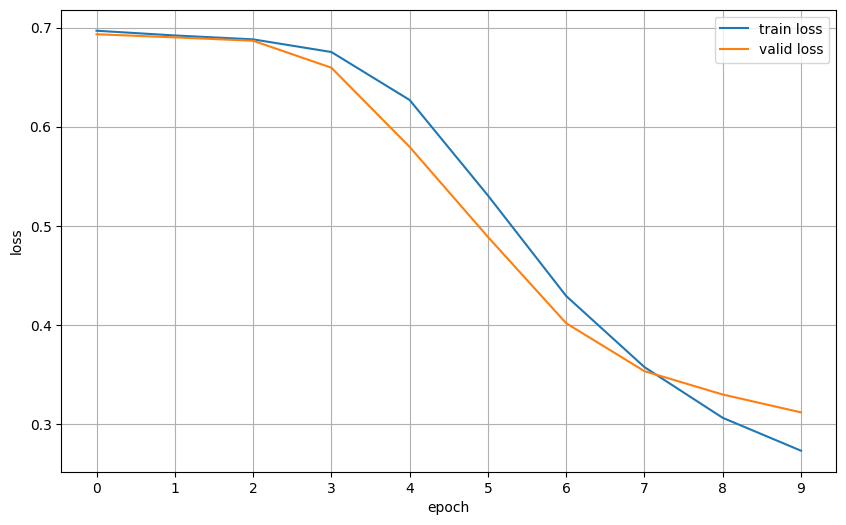

In [ ]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(metrics["train_losses"], label="train loss")
ax.plot(metrics["valid_losses"], label="valid loss")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_xticks(range(n_epochs))
ax.legend()
ax.grid()

### 2.6 Visualisation des Résultats : Courbes de Perte

Ces graphiques sont essentiels pour comprendre le comportement de notre modèle. Ici, nous traçons la `train_loss` (perte sur l'ensemble d'entraînement) et la `valid_loss` (perte sur l'ensemble de validation) au fil des epochs. Idéalement, les deux courbes devraient diminuer. Une situation où la `train_loss` continue de baisser tandis que la `valid_loss` augmente peut indiquer un surapprentissage.

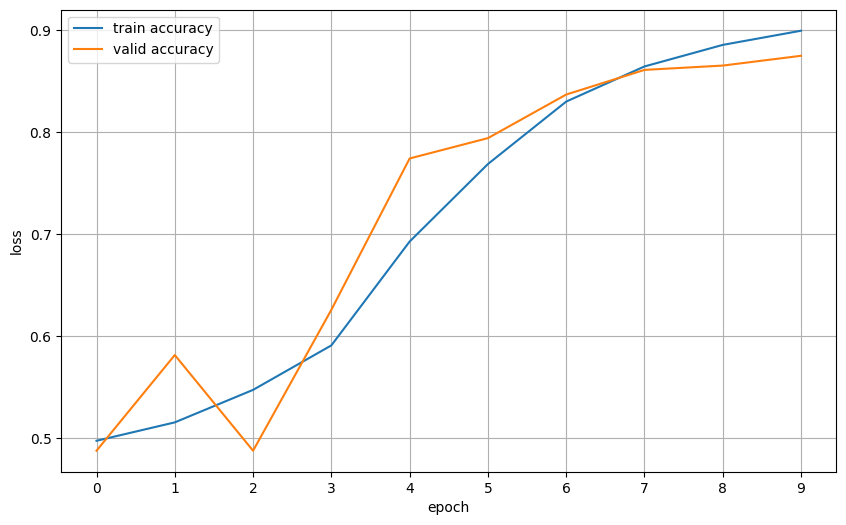

In [ ]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(metrics["train_accs"], label="train accuracy")
ax.plot(metrics["valid_accs"], label="valid accuracy")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_xticks(range(n_epochs))
ax.legend()
ax.grid()

De manière similaire, nous visualisons les courbes de `train_accs` (précision sur l'entraînement) et `valid_accs` (précision sur la validation). L'objectif est que ces deux métriques augmentent et restent proches. Un écart important, où la précision d'entraînement est très élevée mais celle de validation significativement plus basse, est un autre signe de surapprentissage.

In [ ]:
model.load_state_dict(torch.load("mlp.pt")) # Updated filename

test_loss, test_acc = evaluate(test_data_loader, model, criterion, device)

evaluating...: 100%|██████████| 49/49 [00:08<00:00,  5.97it/s]


### 2.7 Évaluation Finale sur l'Ensemble de Test

Une fois l'entraînement terminé, nous chargeons la meilleure version de notre modèle (celle qui a obtenu la plus faible perte de validation) depuis le fichier `mlp.pt`. Nous l'évaluons ensuite une dernière fois sur l'ensemble de test, qui contient des données entièrement nouvelles pour le modèle. Cette étape fournit une mesure fiable de la performance généralisée de notre modèle dans un scénario réel.

In [ ]:
print(f"test_loss: {test_loss:.3f}, test_acc: {test_acc:.3f}")

test_loss: 0.348, test_acc: 0.856


Nous affichons la perte et la précision finales obtenues sur l'ensemble de test. Ces valeurs sont des indicateurs clés de la capacité de notre modèle à prédire correctement le sentiment sur des critiques de films qu'il n'a jamais rencontrées auparavant.

In [ ]:
def predict_sentiment(text, model, tokenizer, vocab, device):
    tokens = tokenizer(text)
    ids = vocab.lookup_indices(tokens)
    tensor = torch.LongTensor(ids).unsqueeze(dim=0).to(device)
    prediction = model(tensor).squeeze(dim=0)
    probability = torch.softmax(prediction, dim=-1)
    predicted_class = prediction.argmax(dim=-1).item()
    predicted_probability = probability[predicted_class].item()
    return predicted_class, predicted_probability

### 2.8 Faire des Prédictions sur de Nouvelles Phrases

La fonction `predict_sentiment` est un outil pratique pour tester directement notre modèle. Elle prend une phrase en texte brut, la tokenise, la numérise, la convertit en un tenseur PyTorch, la soumet au modèle, et retourne la classe prédite (0 pour négatif, 1 pour positif) ainsi que la probabilité associée. Cela nous permet de vérifier le comportement du modèle avec nos propres exemples.

In [ ]:
text = "This film is terrible!"

predict_sentiment(text, model, tokenizer, vocab, device)

(0, 0.9994046688079834)

Nous testons le modèle avec une phrase clairement négative : "This film is terrible!". Nous nous attendons à ce que le modèle prédise la classe 0 (négatif) avec une probabilité élevée.

In [ ]:
text = "This film is great!"

predict_sentiment(text, model, tokenizer, vocab, device)

(1, 0.9999994039535522)

Maintenant, nous utilisons une phrase positive : "This film is great!". L'anticipation est une prédiction de la classe 1 (positif) avec une forte probabilité.